# Indiana Pines

1. Import dependencies

In [1]:
import random
import torch
import multiprocessing
import numpy as np

import torch.utils.data as data

from lightning import Trainer

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    read_fixed_labels_mask,
    pu_bin_train_test_split_by_mask,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.model.hsic import HyperSpectralImageClassifier
from src.visualization.plot import (
    plot_segmentation_comparison,
    plot_epoch_generic,
    plot_masked_segmentation_comparison,
    plot_epoch_generic_comparison,
)

from src.data.dataset_decorator import UnlabeledDatasetDecorator
from src.util.reporting import (
    create_model_name,
    report_run,
    read_report_to_show,
    lightning_metrics,
)
from src.util.list_ext import smooth_moving_average
from src.util.scheduler import CosineLRSchedulerWrapper
from src.util.dict_ext import arrange_and_repeat, unique_counts
from src.definitions import RAW_DATA_FOLDER
from src.util.loss import PuLoss
from src.model.finetune import crete_model_for_fine_tune

2. Prepare env

In [2]:
target_class = 11
data_point_count = 245

In [3]:
learning_rate = 1e-3
weight_decay = 0
num_epochs = 60

In [4]:
batch_size = 24
patch_size = 9
target_dim = 75

examples_per_class = {}

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [5]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [6]:
torch.cuda.empty_cache()

In [7]:
torch.set_float32_matmul_precision("medium")

In [8]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [9]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [10]:
_, image = preprocess_hsi(image, pre_process_type)

In [11]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, device, random_seed
)

In [12]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [13]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

In [14]:
examples_per_class = arrange_and_repeat(num_classes, 20)

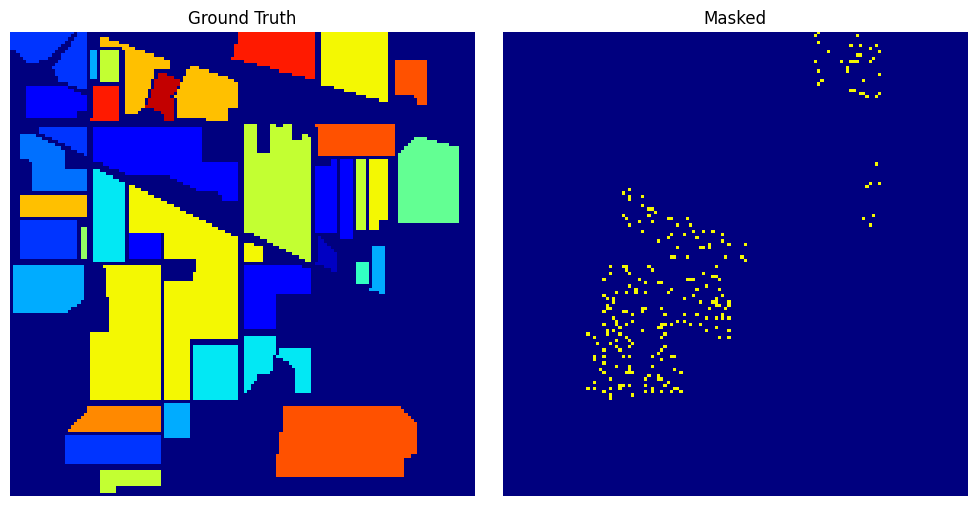

In [15]:
mask = read_fixed_labels_mask(
    f"indian-pines-train-test-split-{target_class}-{data_point_count}.npy",
    folder=RAW_DATA_FOLDER / "mask" / "train-test-split",
)

x_train, y_train, _, _ = pu_bin_train_test_split_by_mask(target_class, x, y, mask)

# p_indices = np.where(y_train == 1)[0]
# u_indices = np.where(y_train == -1)[0]

# p_count = len(p_indices)

# selected_u_indecies = np.random.choice(u_indices, size=p_count, replace=False)

# balanced_indices = np.concatenate([p_indices, selected_u_indecies])

# np.random.shuffle(balanced_indices)

# x_train = x_train[balanced_indices]
# y_train = y_train[balanced_indices]

_ = plot_masked_segmentation_comparison(y.reshape(image_h, image_w), mask)

In [16]:
y_train_unique = unique_counts(y_train)

y_train_unique

{-1: 20780, 1: 245}

In [17]:
y_target = y == target_class

In [18]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y_target, dtype=torch.long)
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [19]:
x_tensor.shape

torch.Size([21025, 75, 9, 9])

In [20]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 24'

In [21]:
train_dataset = data.TensorDataset(x_train_tensor, y_train_tensor)
full_dataset = data.TensorDataset(x_tensor, y_tensor)

train_loader = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=cpu_count,
    persistent_workers=True,
)
full_loader = data.DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)
predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
    num_workers=cpu_count,
    persistent_workers=True,
)

4. Train model

In [22]:
positive_count = (y == target_class).sum()
all_count = len(y)
positive_prob = torch.tensor(positive_count / all_count, dtype=torch.float32)

In [23]:
print(f"{target_class} count: {positive_count}")
print(f"Overall count: {all_count}")
print(f"Class prob: {positive_prob}")

11 count: 2455
Overall count: 21025
Class prob: 0.11676575243473053


In [24]:
def extract_prediction(y_hat):
    return (torch.sigmoid(y_hat) > 0.5).to(dtype=torch.int)

In [25]:
backbone_model = crete_model_for_fine_tune(256, 1, "indian_pines_mae_encoder_1754996290", flatten_out=True)

In [26]:
loss = PuLoss(
    prior=positive_prob,
    nnpu=True,
    loss_fn=lambda x: torch.nn.functional.softplus(-x),
)

In [27]:
model = HyperSpectralImageClassifier(
    backbone_model,
    2,
    lr=learning_rate,
    weight_decay=weight_decay,
    loss_fun=loss,
    pred_extractor=extract_prediction,
    scheduler=lambda optimizer: CosineLRSchedulerWrapper(
        optimizer,
        t_initial=num_epochs,
        lr_min=learning_rate * 0.01,
        warmup_t=int(np.ceil(0.1 * num_epochs)),
        warmup_lr_init=learning_rate * 0.01,
    ),
)

trainer = Trainer(accelerator="auto", max_epochs=num_epochs)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/melal/Workspace/hsi-classification-playground/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [28]:
trainer.fit(
    model,
    train_loader,
    full_loader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | FineTuneModel        | 181 K  | train
1 | loss_fun         | PuLoss               | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy   | 0      | train
4 | average_accuracy | MulticlassAccuracy   | 0      | train
5 | kappa            | MulticlassCohenKappa | 0      | train
------------------------------------------------------------------
181 K     Trainable params
0         Non-trainable params
181 K     Total params
0.726     Total estimated model params size (MB)
7         Modules in train mode
42        Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


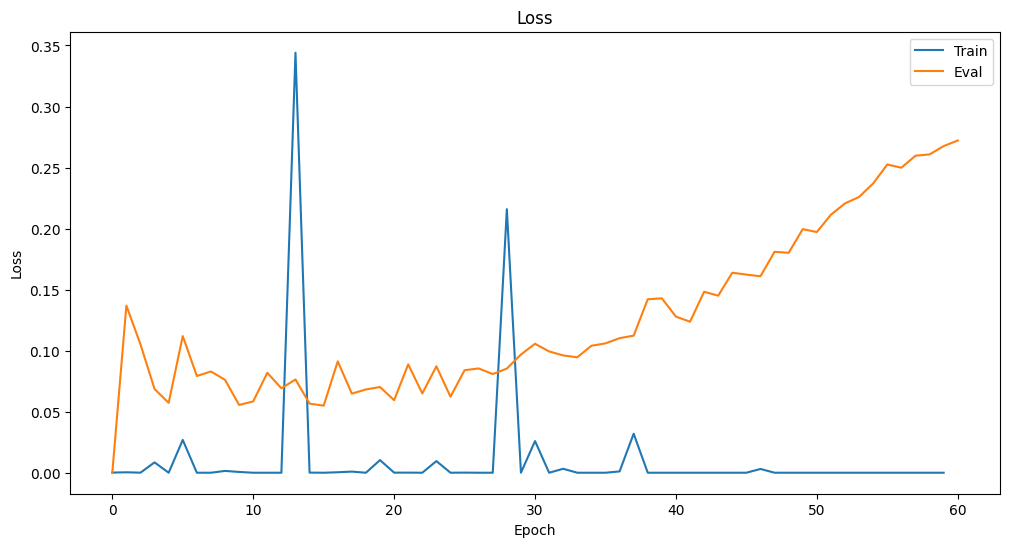

In [29]:
smothed_train = smooth_moving_average([it.loss.cpu() for it in model.train_metrics], 1)
smothed_eval = smooth_moving_average([it.loss.cpu() for it in model.val_metrics], 1)

plot_epoch_generic_comparison(smothed_train, smothed_eval)

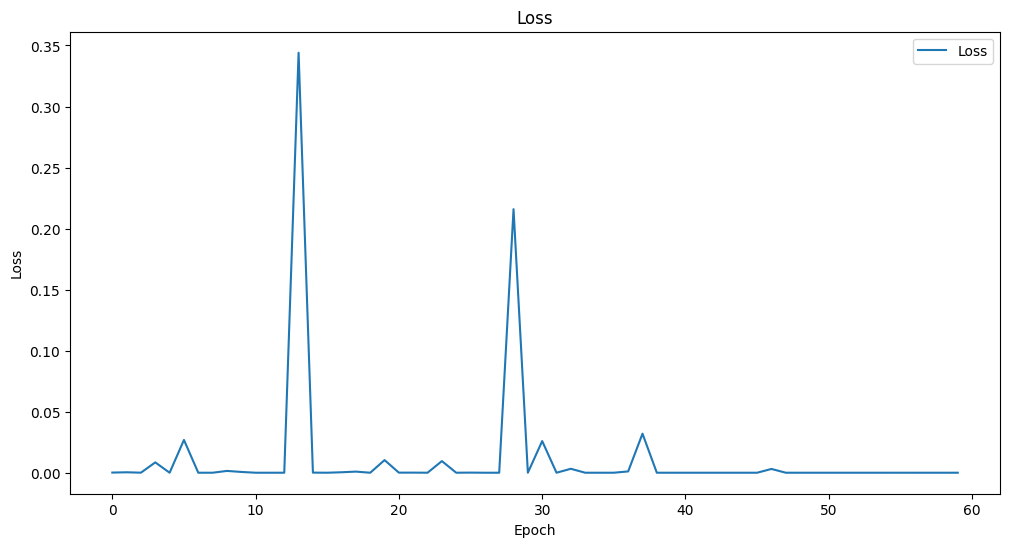

In [30]:
smothed_train = smooth_moving_average([it.loss.cpu() for it in model.train_metrics], 1)

plot_epoch_generic(smothed_train, desc="Loss")

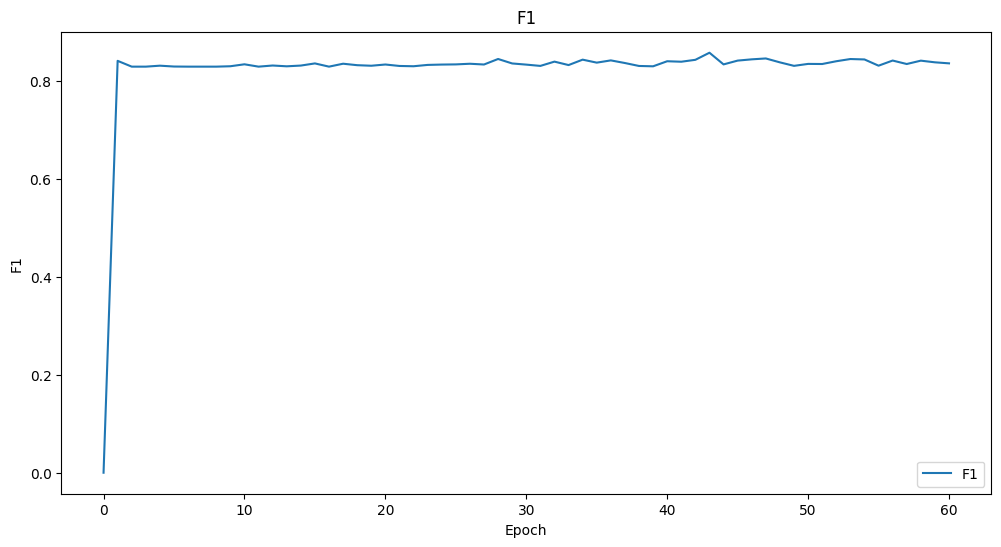

In [31]:
smooth_f1 = smooth_moving_average([it.f1.cpu() for it in model.val_metrics], 1)

plot_epoch_generic(smooth_f1, desc="F1")

In [32]:
validation_result = trainer.validate(model, full_loader)

validation_result

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy       0.886040449142456
         val_f1             0.8351882100105286
        val_kappa           0.04168498516082764
        val_loss            0.27215781807899475
  val_overall_accuracy      0.5120162963867188
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 0.27215781807899475,
  'val_f1': 0.8351882100105286,
  'val_overall_accuracy': 0.5120162963867188,
  'val_average_accuracy': 0.886040449142456,
  'val_kappa': 0.04168498516082764}]

2. Display prediction

In [33]:
y_pred = trainer.predict(model, predict_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [34]:
y_pred = torch.cat(y_pred, dim=0)
y_pred = extract_prediction(y_pred)
y_pred = y_pred.reshape(image_h, image_w)

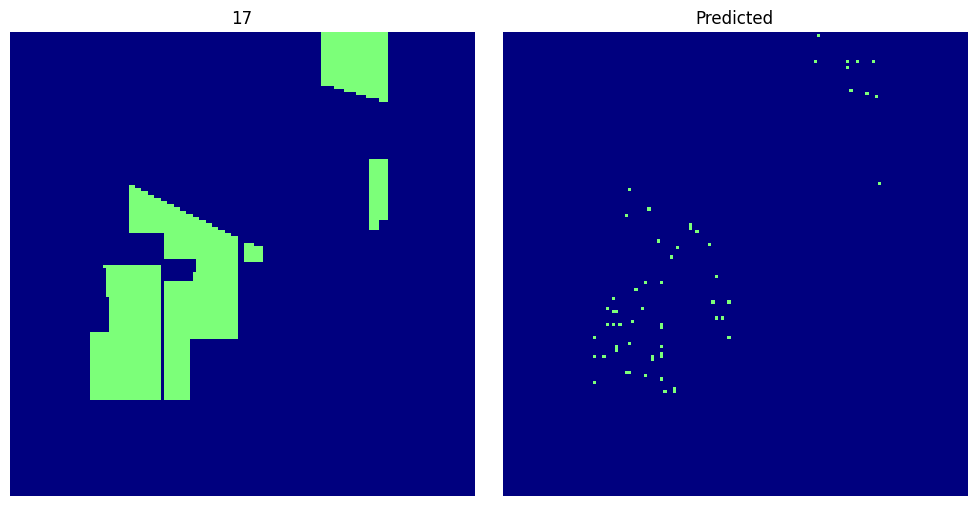

In [35]:
plot_segmentation_comparison(y_target.reshape(image_h, image_w), y_pred.numpy(), num_classes)

6. Write report

In [36]:
model_name = create_model_name("indian_pines_", {target_class: y_train_unique[1]})
model_category = "dbda"

In [37]:
run_params = {
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "patch_size": patch_size,
    "target_dim": target_dim,
    "pre_process_type": str(pre_process_type),
    "dim_reduction_type": str(dim_reduction_type),
}

report_run(
    model_name=model_name,
    model_category=model_category,
    run_desc="More epochs + MAE pretrain",
    run_params=run_params | model.get_params(),
    run_metrics=lightning_metrics(validation_result),
)

PosixPath('/home/melal/Workspace/hsi-classification-playground/reports/runs/indian_pines__11-245.csv')

In [38]:
read_report_to_show(model_name, sort_by_metric="f1")

,timestamp,model_category,run_desc,params,loss,f1,OA,AA,kappa
0,2025-08-12T14:02:39.273827+00:00,dbda,More epochs + MAE pretrain,"{""num_epochs"": 60, ""batch_size"": 24, ""patch_si...",0.272158,0.835188,0.512016,0.88604,0.041685


In [39]:
read_report_to_show(model_name, sort_by_metric="f1", model_category=model_category)

,timestamp,run_desc,params,loss,f1,OA,AA,kappa
0,2025-08-12T14:02:39.273827+00:00,More epochs + MAE pretrain,"{""num_epochs"": 60, ""batch_size"": 24, ""patch_si...",0.272158,0.835188,0.512016,0.88604,0.041685
